### Import library

In [2]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Plotting style
plt.style.use('ggplot')
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Model training & dataset splitting
from sklearn.model_selection import train_test_split, KFold, cross_val_score

# Regression models
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from lightgbm import LGBMRegressor
import xgboost as xgb

# Evaluation metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    confusion_matrix
)

# Additional visualization
import plotly.express as px

# For checking text encoding
import chardet

# Hyperparameter tuning
import optuna
import lightgbm as lgb

### Data loading

In [10]:
# Load a CSV file that contains Korean characters using EUC-KR encoding
train_df = pd.read_csv('/Users/seungoh/Library/Mobile Documents/com~apple~CloudDocs/2025년/공모전/DATA/TRAIN_DATA.csv', encoding = 'EUC-KR')
# Display the first few rows to verify correct loading
print(train_df.head())
print(train_df.info())

   DATA_YM  AREA_ID AREA_NM  DIST_CD DIST_NM  TOTAL_BIDG  FAC_NEIGH_1  \
0   202303     9626  중앙로역_4    27110      중구       538.0        266.0   
1   202303    10350    황리단길    47130     경주시       765.0         72.0   
2   202212     9547    농소1동    31200      북구       343.0         74.0   
3   202312     9995  심석고등학교    41360    남양주시       129.0          4.0   
4   202301     9248     고덕역    11740     강동구        34.0          2.0   

   FAC_NEIGH_2  FAC_CULT_MTG  FAC_RELG  FAC_RETAIL  FAC_MEDI  FAC_YOSE  \
0         88.0           6.0       3.0         2.0       3.0       0.0   
1        174.0           1.0       0.0         2.0       0.0       1.0   
2        161.0           1.0       3.0         0.0       2.0       6.0   
3         14.0           0.0       1.0         0.0       0.0       0.0   
4         14.0           0.0       0.0         1.0       0.0       1.0   

   FAC_TRAIN  FAC_SPORT  FAC_STAY  FAC_LEISURE  TOTAL_GAS  CMRC_GAS  \
0        0.0        0.0      16.0          3.

### EDA

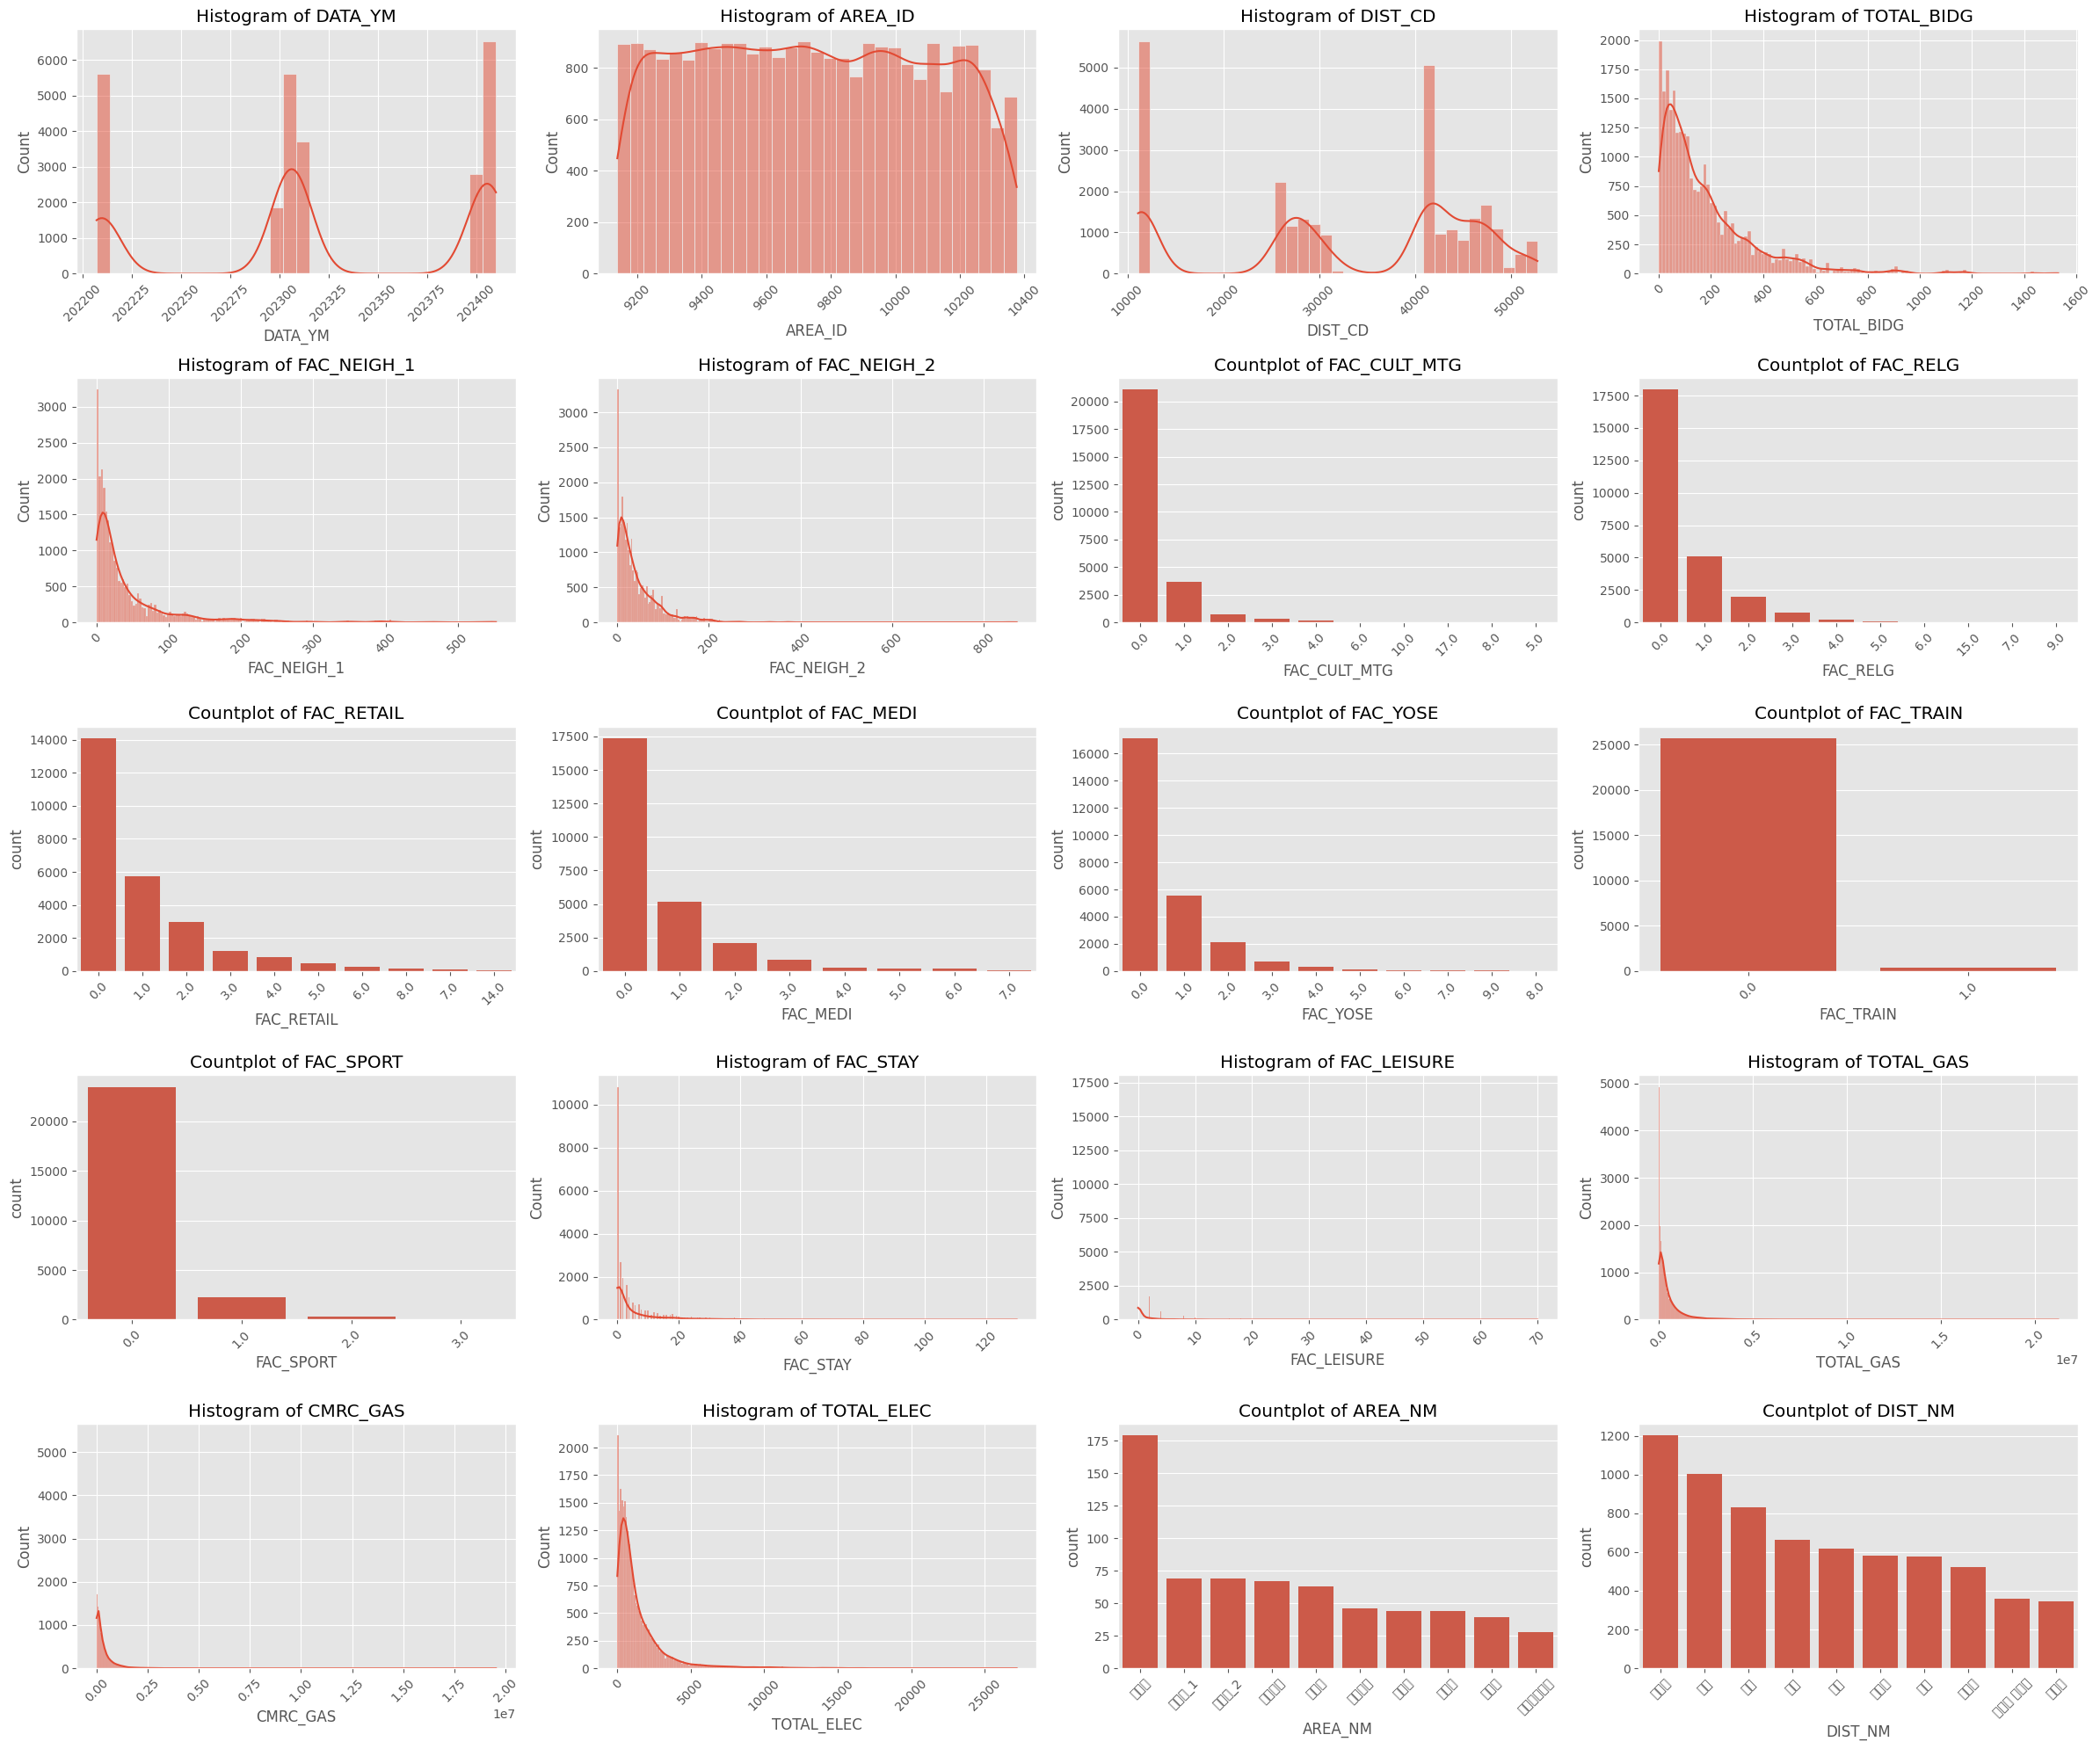

In [8]:
# Data visualization
def eda_plot(df, cols=None):

    # If no columns are specified, use all numerical and categorical columns
    if cols is None:
        num_cols = df.select_dtypes(include=np.number).columns.tolist()
        cat_cols = df.select_dtypes(include='object').columns.tolist()
        cols = num_cols + cat_cols

    n = len(cols)
    nrows, ncols = 5, 4  # Fixed 4x5 subplots
    figsize = (24, 20)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = axes.flatten()

    for i, col in enumerate(cols):
        # If column is categorical or has fewer than 20 unique values, use countplot
        if df[col].dtype == 'object' or df[col].nunique() < 20:
            sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index[:10])
            axes[i].set_title(f"Countplot of {col}")
        else:
            # Otherwise, use histogram with KDE for numerical variables
            sns.histplot(data=df, x=col, kde=True, ax=axes[i])
            axes[i].set_title(f"Histogram of {col}")

        axes[i].tick_params(axis='x', rotation=45)

    # Remove unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

eda_plot(train_df)

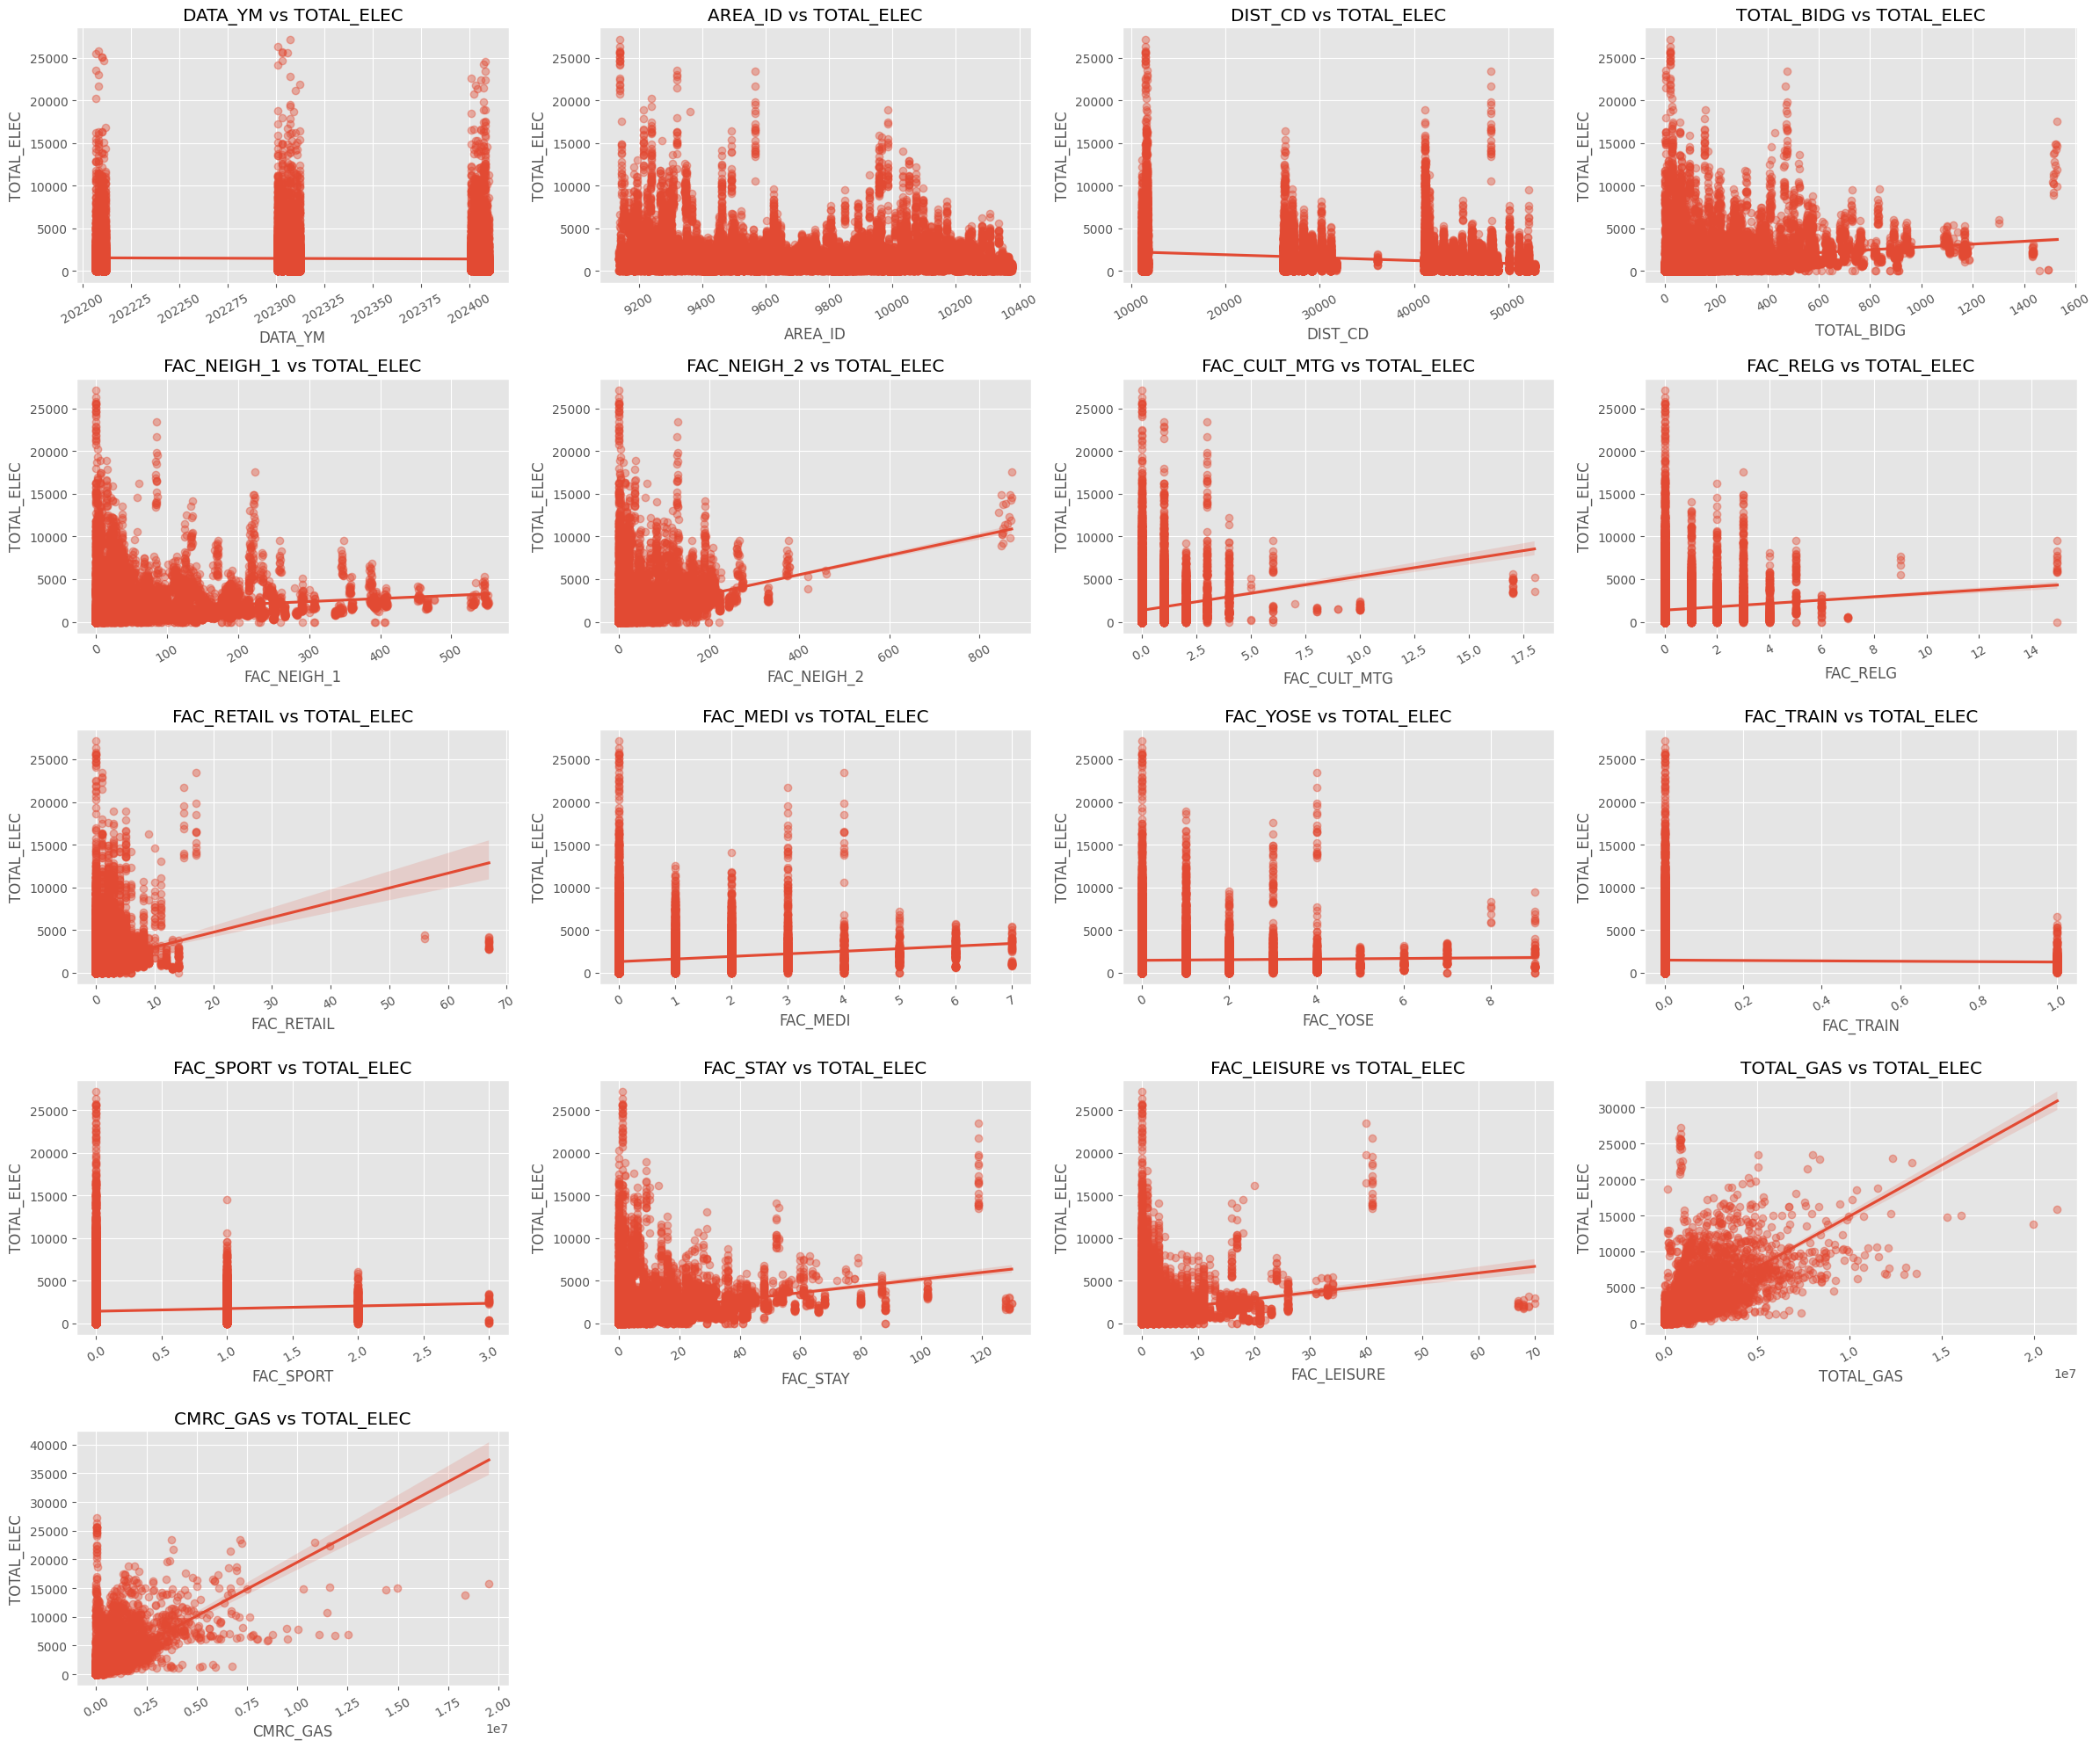

In [9]:
def regression_plot(df):
  
    target_col = df.columns[-1]
    num_cols = df.select_dtypes(include=np.number).columns.tolist()

    if target_col not in num_cols:
        print(f"The last column `{target_col}` is not numerical.")
        return

    # Select only numerical input variables excluding the target
    num_cols = [col for col in num_cols if col != target_col]

    n = len(num_cols)
    nrows, ncols = 5, 4
    figsize = (24, 20)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        # Scatter plot with regression line
        sns.regplot(data=df, x=col, y=target_col, ax=axes[i], scatter_kws={'alpha':0.4})
        axes[i].set_title(f"{col} vs {target_col}")
        axes[i].tick_params(axis='x', rotation=30)

    # Remove unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

regression_plot(train_df)

### Data preprocessing Section

In [11]:
# Remove rows with missing values
train_df = train_df.dropna()

# Convert to datetime format
train_df['DATA_YM'] = pd.to_datetime(train_df['DATA_YM'], format='%Y%m')

# Extract year and month from date
train_df['YEAR'] = train_df['DATA_YM'].dt.year
train_df['MONTH'] = train_df['DATA_YM'].dt.month

# Drop original date column
train_df = train_df.drop(['DATA_YM'], axis=1)

# Make a copy of the cleaned dataframe
df = train_df.copy()

# Commercial gas usage ratio (commercial / total gas)
df['CMRC_GAS_RATIO'] = df['CMRC_GAS'] / df['TOTAL_GAS']

# Average gas consumption per building
df['AVG_GAS_PER_BUILDING'] = df['TOTAL_GAS'] / (df['TOTAL_BIDG'] + 1)

# Number of Type-1 convenience facilities per building
df['FAC1_PER_BUILDING'] = df['FAC_NEIGH_1'] / (df['TOTAL_BIDG'] + 1)

# Number of Type-2 convenience facilities per building
df['FAC2_PER_BUILDING'] = df['FAC_NEIGH_2'] / (df['TOTAL_BIDG'] + 1)

# Add cyclical features for month using sine and cosine transformations
df['MONTH_SIN'] = np.sin(2 * np.pi * df['MONTH'] / 12)
df['MONTH_COS'] = np.cos(2 * np.pi * df['MONTH'] / 12)

# Apply Label Encoding to categorical variables
le_dist_nm = LabelEncoder()
df['DIST_NM'] = le_dist_nm.fit_transform(df['DIST_NM'].astype(str))

le_area_nm = LabelEncoder()
df['AREA_NM'] = le_area_nm.fit_transform(df['AREA_NM'].astype(str))

le_dist_cd = LabelEncoder()
df['DIST_CD'] = le_dist_cd.fit_transform(df['DIST_CD'].astype(str))

le_area_id = LabelEncoder()
df['AREA_ID'] = le_area_id.fit_transform(df['AREA_ID'].astype(str))

# Save the name of the target variable
target_col = 'TOTAL_ELEC'

# Reorder columns to place the target at the end
df = df[[col for col in df.columns if col != target_col] + [target_col]]

# Drop the original 'MONTH' column (now replaced by cyclical features)
df = df.drop(['MONTH'], axis=1)

# Split the dataset into features (X) and target (y)
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print(X)
print(y)

       AREA_ID  AREA_NM  DIST_CD  DIST_NM  TOTAL_BIDG  FAC_NEIGH_1  \
0          806      962       41      174       538.0        266.0   
1          302     1135      199       11       765.0         72.0   
2          729      207       69       84       343.0         74.0   
3         1161      637       96       49       129.0          4.0   
4          437       73       24        2        34.0          2.0   
...        ...      ...      ...      ...         ...          ...   
26094      991      647      260      167        85.0         13.0   
26095      137      410       52       83       334.0        155.0   
26096     1030       83      174       19       311.0        135.0   
26097      237     1119      136      194        62.0          9.0   
26098      177     1033       62      174       262.0         36.0   

       FAC_NEIGH_2  FAC_CULT_MTG  FAC_RELG  FAC_RETAIL  ...  FAC_LEISURE  \
0             88.0           6.0       3.0         2.0  ...          3.0   
1      

###  Hyperparameter Tuning for Each Model

In [12]:
# ------------------------------
# Optuna for XGBoost Regressor
# ------------------------------
def objective_xgb(trial):
    params = {
        'objective': 'reg:squarederror',
        'n_estimators': trial.suggest_int('n_estimators', 100, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42,
    }

    # 5-fold cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    model = xgb.XGBRegressor(**params)

    # Return negative RMSE (Optuna minimizes the objective function)
    scores = cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
    return -1 * scores.mean()

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=50)
best_params_xgb = study_xgb.best_params
print("✅ Best Params (XGBoost):", best_params_xgb)


# ------------------------------
# Optuna for LightGBM Regressor
# ------------------------------
def objective_lgb(trial):
    params = {
        'objective': 'regression',
        'n_estimators': trial.suggest_int('n_estimators', 100, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42,
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    model = LGBMRegressor(**params)

    scores = cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
    return -1 * scores.mean()

study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=50)
best_params_lgbm = study_lgb.best_params
print("✅ Best Params (LightGBM):", best_params_lgbm)


# ------------------------------
# Optuna for Random Forest Regressor
# ------------------------------
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 3000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['auto', 'sqrt', 'log2']),
        'random_state': 42,
        'n_jobs': -1
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    model = RandomForestRegressor(**params)

    scores = cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
    return -1 * scores.mean()

study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(objective_rf, n_trials=50)
best_params_rf100 = study_rf.best_params
print("✅ Best Params (RandomForest):", best_params_rf100)

[I 2025-05-22 19:40:15,752] A new study created in memory with name: no-name-c9b69f44-3ad5-414d-a5af-c31a1beb0c23
[I 2025-05-22 19:41:54,169] Trial 0 finished with value: 377.57575578684765 and parameters: {'n_estimators': 2158, 'learning_rate': 0.10000945746858203, 'max_depth': 10, 'subsample': 0.5318167280486268, 'colsample_bytree': 0.9781137477961923}. Best is trial 0 with value: 377.57575578684765.
[I 2025-05-22 19:42:42,829] Trial 1 finished with value: 361.5502990472326 and parameters: {'n_estimators': 1522, 'learning_rate': 0.14342090540304145, 'max_depth': 8, 'subsample': 0.8886167205407338, 'colsample_bytree': 0.7377288396885058}. Best is trial 1 with value: 361.5502990472326.
[I 2025-05-22 19:45:01,976] Trial 2 finished with value: 360.02419499483113 and parameters: {'n_estimators': 2697, 'learning_rate': 0.12977123125149292, 'max_depth': 10, 'subsample': 0.8909846693191996, 'colsample_bytree': 0.5326045513156059}. Best is trial 2 with value: 360.02419499483113.
[I 2025-05-22

KeyboardInterrupt: 

In [ ]:
# 랜덤포레스트 파라미터
best_params_rf_100 = {
    "n_estimators": 959,
    "max_depth": 28,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "max_features": "sqrt",
    "bootstrap": False,
    "random_state": 42  # 추가 (재현성 확보)
}



# lgbm 파라미터
best_params_lgbm = {
    "n_estimators": 1999,
    "learning_rate": 0.07643352742632968,
    "max_depth": 10,
    "num_leaves": 48,
    "min_child_samples": 18,
    "subsample": 0.6086478311878462,
    "colsample_bytree": 0.8384187201464204,
    "reg_alpha": 0.819505385066028,
    "reg_lambda": 0.308772353150567,
    "boosting_type": "gbdt",
    "objective": "regression",
    "random_state": 42
}

#xgbooast 파라미타
best_params_xgb = {
    'n_estimators': 2759,
    'learning_rate': 0.03507826653059297,
    'max_depth': 7,
    'subsample': 0.7813780791473511,
    'colsample_bytree': 0.8074608951935128,
    'objective': 'reg:squarederror',
    'random_state': 42
}

### Evaluation of Each model

In [ ]:
def evaluate_lgb_kfold(X, y, best_params_lgbm, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    rmse_list = []

    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = lgb.LGBMRegressor(**best_params_lgbm)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        rmse_list.append(rmse)
        feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': model.feature_importances_})
        feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

    print(f"LGBM Mean RMSE: {np.mean(rmse_list):.4f}")
    print(f"📉 Standard Deviation: {np.std(rmse_list):.4f}")
    print(feature_importance)
    return rmse_list


def evaluate_xgb_kfold(X, y, best_params_xgb, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    rmse_list = []

    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = xgb.XGBRegressor(**best_params_xgb)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        rmse_list.append(rmse)
        feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': model.feature_importances_})
        feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

    print(f"XGBoost Mean RMSE: {np.mean(rmse_list):.4f}")
    print(f"📉 Standard Deviation: {np.std(rmse_list):.4f}")
    print(feature_importance)
    return rmse_list

In [ ]:
evaluate_lgb_kfold(X,y,best_params_lgbm)
evaluate_xgb_kfold(X,y,best_params_xgb)

### Esemble model

In [ ]:
# KFold configuration
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scores = []

for train_idx, val_idx in kf.split(X):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Instantiate new models for each fold
    lgb_model = LGBMRegressor(**best_params_lgbm)
    xgb_model = xgb.XGBRegressor(**best_params_xgb)

    # Ensemble model (weights can be adjusted as needed)
    ensemble_model = VotingRegressor(
        estimators=[
            ('lgb', lgb_model),
            ('xgb', xgb_model)
        ],
        weights=[0.4, 0.6]  # Example: assign higher weight to XGBoost
    )

    # Train ensemble model
    ensemble_model.fit(X_tr, y_tr)
    
    # Predict on validation set
    y_pred = ensemble_model.predict(X_val)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    rmse_scores.append(rmse)

# Final output
print(f"✅ Average RMSE of Ensemble Model (KFold): {np.mean(rmse_scores):.2f}")
print(f"📉 Standard Deviation: {np.std(rmse_scores):.2f}")

### Test dataset preprocessing and Prediction

In [ ]:
# Load test data
test_df = pd.read_csv("/Users/seungoh/Library/Mobile Documents/com~apple~CloudDocs/2025년/공모전/DATA/TEST_DATA.csv", encoding='EUC-KR')

#  Convert 'DATA_YM' to datetime and extract year/month
test_df['DATA_YM'] = pd.to_datetime(test_df['DATA_YM'], format='%Y%m')
test_df['YEAR'] = test_df['DATA_YM'].dt.year
test_df['MONTH'] = test_df['DATA_YM'].dt.month
test_df = test_df.drop(['DATA_YM'], axis=1)

#  Generate derived features
test_df['CMRC_GAS_RATIO'] = test_df['CMRC_GAS'] / test_df['TOTAL_GAS']
test_df['AVG_GAS_PER_BUILDING'] = test_df['TOTAL_GAS'] / (test_df['TOTAL_BIDG'] + 1)
test_df['FAC1_PER_BUILDING'] = test_df['FAC_NEIGH_1'] / (test_df['TOTAL_BIDG'] + 1)
test_df['FAC2_PER_BUILDING'] = test_df['FAC_NEIGH_2'] / (test_df['TOTAL_BIDG'] + 1)
test_df['MONTH_SIN'] = np.sin(2 * np.pi * test_df['MONTH'] / 12)
test_df['MONTH_COS'] = np.cos(2 * np.pi * test_df['MONTH'] / 12)

#  Apply the same LabelEncoders from training
test_df['DIST_NM'] = le_dist_nm.transform(test_df['DIST_NM'].astype(str))
test_df['AREA_NM'] = le_area_nm.transform(test_df['AREA_NM'].astype(str))
test_df['DIST_CD'] = le_dist_cd.transform(test_df['DIST_CD'].astype(str))
test_df['AREA_ID'] = le_area_id.transform(test_df['AREA_ID'].astype(str))

#  Align features with training data
X_test = test_df[X.columns]

#  Retrain final model on full training data
final_lgb = LGBMRegressor(**best_params_lgbm)
final_xgb = xgb.XGBRegressor(**best_params_xgb)

ensemble_model = VotingRegressor(
    estimators=[
        ('lgb', final_lgb),
        ('xgb', final_xgb)
    ],
    weights=[0.4, 0.6]
)

ensemble_model.fit(X, y)  # Retrain on the full dataset

#  Make predictions
y_pred = ensemble_model.predict(X_test)
y_pred = np.clip(y_pred, 0, None)  # Clip negative predictions to 0

# Export predictions to Excel
submission = pd.DataFrame({'y_pred': y_pred})
submission.to_excel("final_predict.xlsx", index=False)